In [171]:
import os
base_path = 'd:/'
#base_path = '/home/martin/data_imaging/Muscle/'
# data path for the sherpas study
participants_data_filename = base_path + "/data_sherpas/ParticipantsDemographics.xlsx"
pelvis_mri_results_path = base_path + "/data_sherpas/ReprocessedCropped/"
lumbar_mri_results_path = base_path + "/data_sherpas/LumbarSpineReprocessed/"
output_path =  "G:/My Drive/Work/Publications/2025_CoreScore/SubmissionSkeletalRadiology/Rev1/Results/"

# data path for the cto5k study
#results_cto5k_filename = "D:/Work/Publications/2025_CoreScore/DataAnalysis/CoreScore/merged_data.csv"
cto5k_participants_data_filename = base_path + "/data_cto5k_cyclists/FullStudyDemographics.xlsx"
lumbar_mri_cto5k_results_path = base_path + "/data_cto5k_cyclists/AllData/Reprocessed/"
pelvis_mri_cto5k_results_path = base_path + "/data_cto5k_cyclists/AllCroppedData/Reprocessed/"

volume_ff_filename_per_subject = "volumes_and_ffs.csv"
muscle_length_mm_filename_per_subject = "muscle_lengths_mm.csv"
column_names_pelvis = ["VOL_LGMAX", "VOL_LGMED", "VOL_LGMIN", "VOL_LTFL", "VOL_RGMAX", "VOL_RGMED", "VOL_RGMIN", "VOL_RTFL",
                "FF_LGMAX", "FF_LGMED", "FF_LGMIN", "FF_LTFL", "FF_RGMAX", "FF_RGMED", "FF_RGMIN", "FF_RTFL"]
column_names_lumbar = ["VOL_LPSOAS", "VOL_LILIACUS", "VOL_LQUADRATUS", "VOL_LM+ES", "VOL_RPSOAS", "VOL_RILIACUS", "VOL_RQUADRATUS", "VOL_RM+ES",
                       "FF_LPSOAS", "FF_LILIACUS", "FF_LQUADRATUS", "FF_LM+ES", "FF_RPSOAS", "FF_RILIACUS", "FF_RQUADRATUS", "FF_RM+ES"]

os.makedirs(output_path, exist_ok=True)

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy as scipy  
import scipy.stats as stats
print(f"statsmodels version: {sm.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"pandas version: {pd.__version__}")

# Load the data for the cto5k study
data_cto5k = pd.read_excel(cto5k_participants_data_filename, sheet_name='All by Number')


statsmodels version: 0.14.5
scipy version: 1.13.1
pandas version: 2.3.3


In [172]:
# Load couch to 5k data to use as a reference:
# Get all subfolders in pelvis_mri_results_path
subfolders = [f.path for f in os.scandir(pelvis_mri_cto5k_results_path) if f.is_dir()]
# For each subfolder, match to ID and add volume/ff data
for folder in subfolders:
    folder_name = os.path.basename(folder)
    # Find matching row in data
    idx = data_cto5k.index[data_cto5k['Study ID C'] == folder_name]
    if not idx.empty:
        csv_path = os.path.join(folder, volume_ff_filename_per_subject)
        if os.path.exists(csv_path):
            vol_ff_df = pd.read_csv(csv_path, header=None)
            # Assuming single row, add columns to data
            for col in vol_ff_df.columns:
                # Assign values to named columns using column_names_pelvis
                if col > 0 and col <= len(column_names_pelvis):
                    data_cto5k.loc[idx, column_names_pelvis[col-1]] = vol_ff_df.iloc[0][col]

# Do the same for lumbar results
subfolders = [f.path for f in os.scandir(lumbar_mri_cto5k_results_path) if f.is_dir()]
# For each subfolder, match to ID and add volume/ff data
for folder in subfolders:
    folder_name = os.path.basename(folder)
    # Find matching row in data
    idx = data_cto5k.index[data_cto5k['Study ID C'] == folder_name]
    if not idx.empty:
        csv_path = os.path.join(folder, volume_ff_filename_per_subject)
        if os.path.exists(csv_path):
            vol_ff_df = pd.read_csv(csv_path, header=None)
            # Assuming single row, add columns to data
            for col in vol_ff_df.columns:
                # Assign values to named columns using column_names_lumbar
                if col > 0 and col <= len(column_names_lumbar):
                    data_cto5k.loc[idx, column_names_lumbar[col-1]] = vol_ff_df.iloc[0][col]
        csv_path = os.path.join(folder, muscle_length_mm_filename_per_subject)
        if os.path.exists(csv_path):
            length_df = pd.read_csv(csv_path, header=None)
            # Assuming single row, add columns to data
            for col in length_df.columns:
                # Assign values to named columns using column_names_lumbar but replacing VOL_ with LEN_
                if col > 0 and col <= len(column_names_lumbar):
                    muscle_name = column_names_lumbar[col-1][4:]  # Remove 'VOL_' prefix
                    data_cto5k.loc[idx, f'LENGTH_{muscle_name}'] = length_df.iloc[0][col]

# Now rename Sex values 'male' into 'Male', and 'female' into 'Female'
data_cto5k['Sex'] = data_cto5k['Sex'].replace({'male': 'Male', 'female': 'Female'})

# Save the combined data to a new CSV file
combined_data_path = os.path.join(output_path, "combined_data_cto5k.csv")
data_cto5k.to_csv(combined_data_path, index=False)
print(f"Combined data for cto5k saved to {combined_data_path}")

Combined data for cto5k saved to G:/My Drive/Work/Publications/2025_CoreScore/SubmissionSkeletalRadiology/Rev1/Results/combined_data_cto5k.csv


In [173]:
muscles = ['GMAX', 'GMED', 'GMIN', 'TFL', 'PSOAS', 'ILIACUS', 'QUADRATUS', 'M+ES']
# Create filtered data with the subjects with valid data and correct naming:
filtered_data = data_cto5k[data_cto5k['VOL_LGMAX'].notna()].copy()

# Leave only C25K, ACT10, and Cyclists groups:
filtered_data = filtered_data[filtered_data['Group'].isin(['C25K', 'ACT10', 'Cyclists'])]
# Merge C25K and ACT10 groups into a single C25K group
filtered_data['Group'] = filtered_data['Group'].replace({'ACT10': 'C25K'})
# Remove rows with specific subject names
subjects_to_remove = ["ID00114", "ID00129"]
filtered_data = filtered_data[~filtered_data["Study ID"].isin(subjects_to_remove)]

# Rename "Weight (kg)" to "Weight" and "Height (cm)" to "Height"
filtered_data.rename(columns={'Weight (kg)': 'Weight', 'Height (cm)': 'Height'}, inplace=True)

# Add column for BMI
filtered_data['BMI'] = filtered_data['Weight'] / (filtered_data['Height']/100)**2

# If you want to convert volumes from mm^3 to cm^3, uncomment the following line:
vol_columns = [col for col in filtered_data.columns if col.startswith('VOL_')]
filtered_data[vol_columns] = filtered_data[vol_columns] / 1000  

# Compute mean FF and Volume for each muscle (averaging left and right)
for muscle in muscles:
    filtered_data[f'FF_{muscle}'] = (filtered_data[f'FF_L{muscle}'] + filtered_data[f'FF_R{muscle}']) / 2
    filtered_data[f'VOL_{muscle}'] = (filtered_data[f'VOL_L{muscle}'] + filtered_data[f'VOL_R{muscle}']) / 2
for muscle in muscles:
    filtered_data[f'NORM_VOL_{muscle}'] = filtered_data[f'VOL_{muscle}'] / filtered_data['Weight']
    filtered_data[f'LEAN_VOL_{muscle}'] = filtered_data[f'VOL_{muscle}'] * (1-filtered_data[f'FF_{muscle}'])
    # now lean normalised volume:
    filtered_data[f'LEAN_NORM_VOL_{muscle}'] = filtered_data[f'NORM_VOL_{muscle}'] * (1-filtered_data[f'FF_{muscle}'])
    # by height
    filtered_data[f'NORMH_VOL_{muscle}'] = filtered_data[f'VOL_{muscle}'] / filtered_data['Height']
    # now lean normalised volume:
    filtered_data[f'LEAN_NORMH_VOL_{muscle}'] = filtered_data[f'NORMH_VOL_{muscle}'] * (1-filtered_data[f'FF_{muscle}'])
    # by height squared
    filtered_data[f'NORMH2_VOL_{muscle}'] = filtered_data[f'VOL_{muscle}'] / filtered_data['Height']**2
    # now lean normalised volume:
    filtered_data[f'LEAN_NORMH2_VOL_{muscle}'] = filtered_data[f'NORMH2_VOL_{muscle}'] * (1-filtered_data[f'FF_{muscle}'])
# Compute total volume (sum of all muscles) for each subject
filtered_data['VOL_TOTAL'] = filtered_data[[f'VOL_{muscle}' for muscle in muscles]].sum(axis=1)
filtered_data['LEAN_VOL_TOTAL'] = filtered_data[[f'LEAN_VOL_{muscle}' for muscle in muscles]].sum(axis=1)
filtered_data['NORM_VOL_TOTAL'] = filtered_data['VOL_TOTAL'] / filtered_data['Weight']
filtered_data['LEAN_NORM_VOL_TOTAL'] = filtered_data['LEAN_VOL_TOTAL'] / filtered_data['Weight']
# Now convert FF to percentage
ff_columns = [col for col in filtered_data.columns if col.startswith('FF_')]
filtered_data[ff_columns] = filtered_data[ff_columns] * 100
# Compute the FF of the total volume using a weighted average based on the volume of each muscle
filtered_data['FF_TOTAL'] = 0
for muscle in muscles:
    filtered_data['FF_TOTAL'] += filtered_data[f'FF_{muscle}'] * filtered_data[f'VOL_{muscle}']
filtered_data['FF_TOTAL'] = filtered_data['FF_TOTAL'] / filtered_data['VOL_TOTAL']

# Save csv with filtered data
filtered_data_path = os.path.join(output_path, "full_data_results_only_valid.csv")
filtered_data.to_csv(filtered_data_path, index=False)
print(f"Filtered data saved to {filtered_data_path}")


Filtered data saved to G:/My Drive/Work/Publications/2025_CoreScore/SubmissionSkeletalRadiology/Rev1/Results/full_data_results_only_valid.csv


C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\694148941.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  filtered_data['FF_TOTAL'] = 0


In [174]:
from scipy.stats import mannwhitneyu, ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import shapiro

# Compute demographics:
# Compute mean (SD) for age, BMI, years post-transplant, and years of dialysis for each group
group_stats = filtered_data.groupby('Group').agg(
    Age_Mean=('Age', 'mean'),
    Age_SD=('Age', 'std'),
    Age_Min=('Age', 'min'),
    Age_Max=('Age', 'max'),
    BMI_Mean=('BMI', 'mean'),
    BMI_SD=('BMI', 'std'),
    BMI_Min=('BMI', 'min'),
    BMI_Max=('BMI', 'max'),
    Height_Mean=('Height', 'mean'),
    Height_SD=('Height', 'std'),
    Height_Min=('Height', 'min'),
    Height_Max=('Height', 'max'),
    Weight_Mean=('Weight', 'mean'),
    Weight_SD=('Weight', 'std'),
    Weight_Min=('Weight', 'min'),
    Weight_Max=('Weight', 'max'),

    Subject_Count=('Group', 'count'),
    Male_Count=('Sex', lambda x: (x == 'Male').sum()),
    Female_Count=('Sex', lambda x: (x == 'Female').sum()),
    Male_Percentage=('Sex', lambda x: (x == 'Male').mean() * 100),
    Female_Percentage=('Sex', lambda x: (x == 'Female').mean() * 100),

    PAI_inactive=('Physical Activity Index', lambda x: (x == 'Inactive').sum()),
    PAI_modinactive=('Physical Activity Index', lambda x: (x == 'Moderately Inactive').sum()),
    PAI_modactive=('Physical Activity Index', lambda x: (x == 'Moderately Active').sum()),
    PAI_active=('Physical Activity Index', lambda x: (x == 'Active').sum())

)
# Perform statistical tests to assess differences between groups

# Test for differences in Age and BMI between groups
print("\n" + "="*60)
print("Statistical Tests for Differences Between Groups")
print("="*60)
# Check normality of continuous variables (Age, BMI, Height, Weight) for each group

print("\nNormality Tests (Shapiro-Wilk):")
print("-" * 60)

for var in ['Age', 'BMI', 'Height', 'Weight']:
    c25k_data = filtered_data[filtered_data['Group'] == 'C25K'][var].dropna()
    cyclists_data = filtered_data[filtered_data['Group'] == 'Cyclists'][var].dropna()
    
    c25k_stat, c25k_p = shapiro(c25k_data)
    cyclists_stat, cyclists_p = shapiro(cyclists_data)
    
    print(f"\n{var}:")
    print(f"  C25K: W={c25k_stat:.4f}, p={c25k_p:.4f} {'(Normal)' if c25k_p > 0.05 else '(Non-normal)'}")
    print(f"  Cyclists: W={cyclists_stat:.4f}, p={cyclists_p:.4f} {'(Normal)' if cyclists_p > 0.05 else '(Non-normal)'}")
# Age comparison
age_c25k = filtered_data[filtered_data['Group'] == 'C25K']['Age'].dropna()
age_cyclists = filtered_data[filtered_data['Group'] == 'Cyclists']['Age'].dropna()

# Test for normality to decide between t-test and Mann-Whitney U
age_t_stat, age_t_pval = ttest_ind(age_c25k, age_cyclists)
age_u_stat, age_u_pval = mannwhitneyu(age_c25k, age_cyclists)

print(f"\nAge:")
print(f"  t-test: t={age_t_stat:.3f}, p={age_t_pval:.4f}")
print(f"  Mann-Whitney U: U={age_u_stat:.3f}, p={age_u_pval:.4f}")

# BMI comparison
bmi_c25k = filtered_data[filtered_data['Group'] == 'C25K']['BMI'].dropna()
bmi_cyclists = filtered_data[filtered_data['Group'] == 'Cyclists']['BMI'].dropna()

bmi_t_stat, bmi_t_pval = ttest_ind(bmi_c25k, bmi_cyclists)
bmi_u_stat, bmi_u_pval = mannwhitneyu(bmi_c25k, bmi_cyclists)
# Height comparison
height_c25k = filtered_data[filtered_data['Group'] == 'C25K']['Height'].dropna()
height_cyclists = filtered_data[filtered_data['Group'] == 'Cyclists']['Height'].dropna()

height_t_stat, height_t_pval = ttest_ind(height_c25k, height_cyclists)
height_u_stat, height_u_pval = mannwhitneyu(height_c25k, height_cyclists)

print(f"\nHeight:")
print(f"  t-test: t={height_t_stat:.3f}, p={height_t_pval:.4f}")
print(f"  Mann-Whitney U: U={height_u_stat:.3f}, p={height_u_pval:.4f}")

# Weight comparison
weight_c25k = filtered_data[filtered_data['Group'] == 'C25K']['Weight'].dropna()
weight_cyclists = filtered_data[filtered_data['Group'] == 'Cyclists']['Weight'].dropna()

weight_t_stat, weight_t_pval = ttest_ind(weight_c25k, weight_cyclists)
weight_u_stat, weight_u_pval = mannwhitneyu(weight_c25k, weight_cyclists)

print(f"\nWeight:")
print(f"  t-test: t={weight_t_stat:.3f}, p={weight_t_pval:.4f}")
print(f"  Mann-Whitney U: U={weight_u_stat:.3f}, p={weight_u_pval:.4f}")

print(f"\nBMI:")
print(f"  t-test: t={bmi_t_stat:.3f}, p={bmi_t_pval:.4f}")
print(f"  Mann-Whitney U: U={bmi_u_stat:.3f}, p={bmi_u_pval:.4f}")

# Chi-square test for sex distribution

sex_contingency = pd.crosstab(filtered_data['Group'], filtered_data['Sex'])
chi2, chi2_pval, dof, expected = chi2_contingency(sex_contingency)

# Chi-square test for Physical Activity Index distribution
pai_contingency = pd.crosstab(filtered_data['Group'], filtered_data['Physical Activity Index'])
chi2_pai, chi2_pai_pval, dof_pai, expected_pai = chi2_contingency(pai_contingency)

print(f"\nSex Distribution:")
print(f"  Chi-square: χ²={chi2:.3f}, p={chi2_pval:.4f}, df={dof}")
print(f"\n{sex_contingency}")
print(f"\nPhysical Activity Index Distribution:")
print(f"  Chi-square: χ²={chi2_pai:.3f}, p={chi2_pai_pval:.4f}, df={dof_pai}")
print(f"\n{pai_contingency}")
# Add statistical test results to group_stats
group_stats['Age_p_value'] = age_u_pval if age_u_pval < 0.05 else age_t_pval
group_stats['BMI_p_value'] = bmi_u_pval if bmi_u_pval < 0.05 else bmi_t_pval
group_stats['Sex_chi2_p_value'] = chi2_pval
# Print the computed statistics
print(group_stats)


Statistical Tests for Differences Between Groups

Normality Tests (Shapiro-Wilk):
------------------------------------------------------------

Age:
  C25K: W=0.9220, p=0.0001 (Non-normal)
  Cyclists: W=0.9677, p=0.0299 (Non-normal)

BMI:
  C25K: W=0.9253, p=0.0001 (Non-normal)
  Cyclists: W=0.9531, p=0.0034 (Non-normal)

Height:
  C25K: W=0.9902, p=0.7696 (Normal)
  Cyclists: W=0.9897, p=0.7330 (Normal)

Weight:
  C25K: W=0.9663, p=0.0241 (Non-normal)
  Cyclists: W=0.9545, p=0.0042 (Non-normal)

Age:
  t-test: t=0.433, p=0.6652
  Mann-Whitney U: U=3831.500, p=0.6836

Height:
  t-test: t=-0.105, p=0.9164
  Mann-Whitney U: U=3687.000, p=0.9743

Weight:
  t-test: t=6.758, p=0.0000
  Mann-Whitney U: U=5646.500, p=0.0000

BMI:
  t-test: t=8.121, p=0.0000
  Mann-Whitney U: U=6160.500, p=0.0000

Sex Distribution:
  Chi-square: χ²=0.840, p=0.3594, df=1

Sex       Female  Male
Group                 
C25K          42    44
Cyclists      49    37

Physical Activity Index Distribution:
  Chi-squ

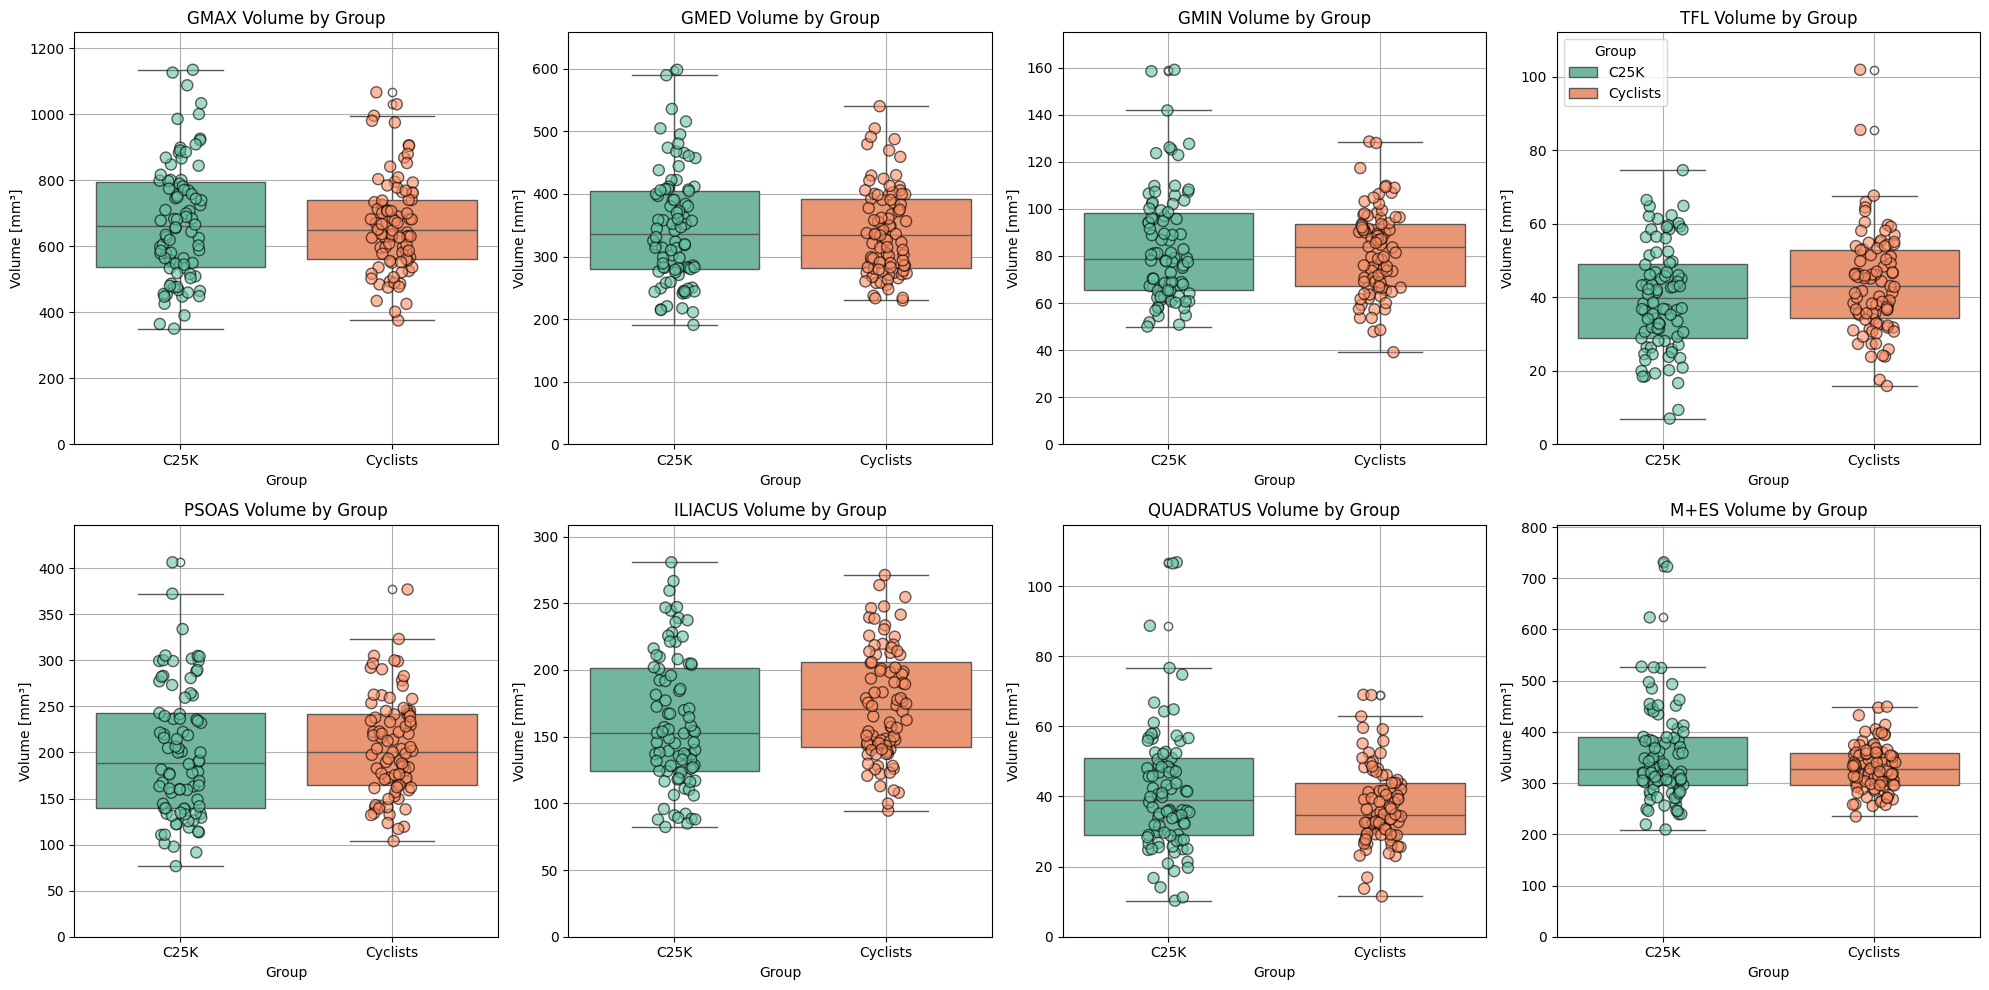

In [175]:
# Plot box plots for volume:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
muscle_list = ['GMAX', 'GMED', 'GMIN', 'TFL', 'PSOAS', 'ILIACUS', 'QUADRATUS', 'M+ES']

for i, muscle in enumerate(muscle_list):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x='Group', y=f'VOL_{muscle}', data=filtered_data, showfliers=True, palette='Set2', hue='Group', legend=True, ax=ax)
    sns.stripplot(
        x='Group', y=f'VOL_{muscle}', data=filtered_data,
        palette='Set2', alpha=0.6, jitter=True, size=8, hue='Group', legend=False,
        edgecolor='black', linewidth=1, ax=ax
    )
    ax.set_ylabel('Volume [mm³]')
    ax.set_title(f'{muscle} Volume by Group')
    ax.grid(True)
    # Set y-axis limit for each subplot based on max volume
    y_max = filtered_data[f'VOL_{muscle}'].max() * 1.1  # 10% higher than max value
    ax.set_ylim(0, y_max)
    # Only show legend for the fourth plot (top right: i == 3)
    if i == 3:
        if ax.get_legend():
            ax.legend(title='Group')
    else:
        if ax.get_legend():
            ax.get_legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(output_path, "boxplot_vol_all_muscles_by_group.png"))
plt.show()


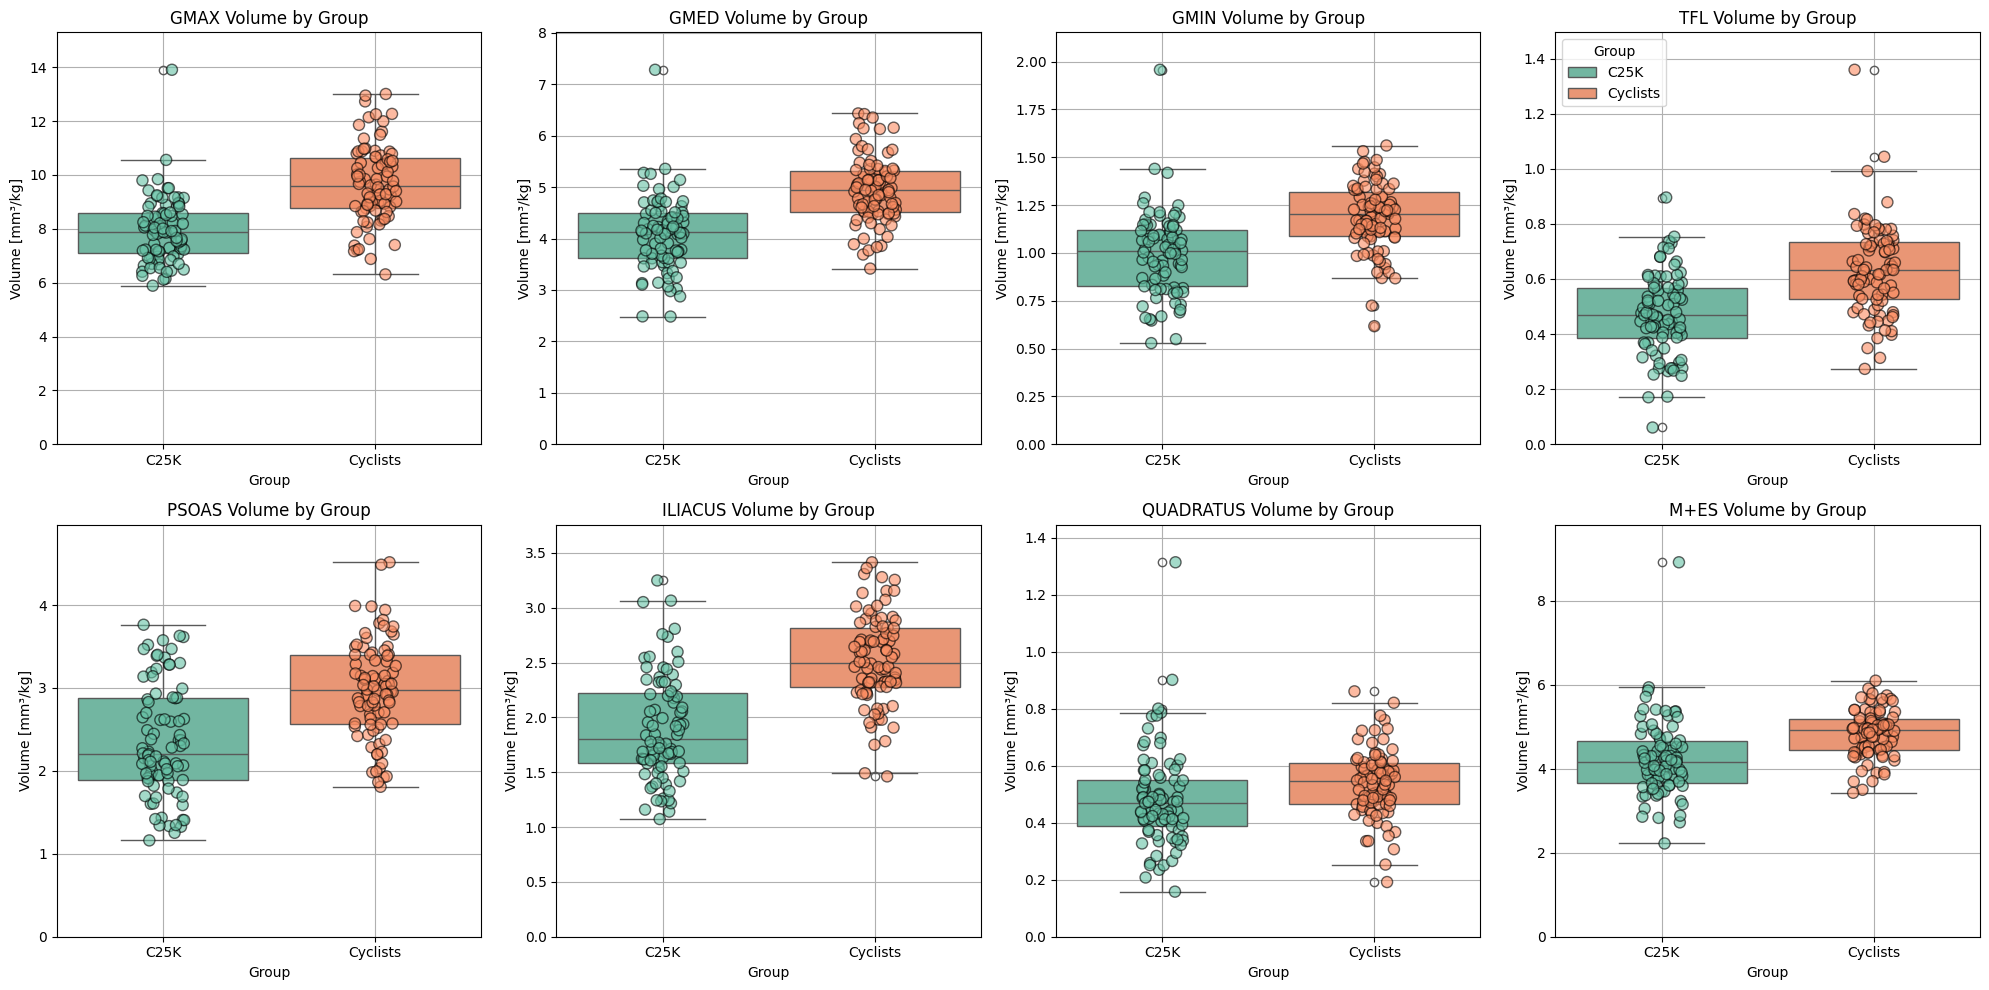

In [176]:
# Plot box plots for volume:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
muscle_list = ['GMAX', 'GMED', 'GMIN', 'TFL', 'PSOAS', 'ILIACUS', 'QUADRATUS', 'M+ES']

for i, muscle in enumerate(muscle_list):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data, showfliers=True, palette='Set2', hue='Group', legend=True, ax=ax)
    sns.stripplot(
        x='Group', y=f'NORM_VOL_{muscle}', data=filtered_data,
        palette='Set2', alpha=0.6, jitter=True, size=8, hue='Group', legend=False,
        edgecolor='black', linewidth=1, ax=ax
    )
    ax.set_ylabel('Volume [mm³/kg]')
    ax.set_title(f'{muscle} Volume by Group')
    ax.grid(True)
    # Set y-axis limit for each subplot based on max volume
    y_max = filtered_data[f'NORM_VOL_{muscle}'].max() * 1.1  # 10% higher than max value
    ax.set_ylim(0, y_max)
    # Only show legend for the fourth plot (top right: i == 3)
    if i == 3:
        if ax.get_legend():
            ax.legend(title='Group')
    else:
        if ax.get_legend():
            ax.get_legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(output_path, "boxplot_norm_vol_all_muscles_by_group.png"))
plt.show()

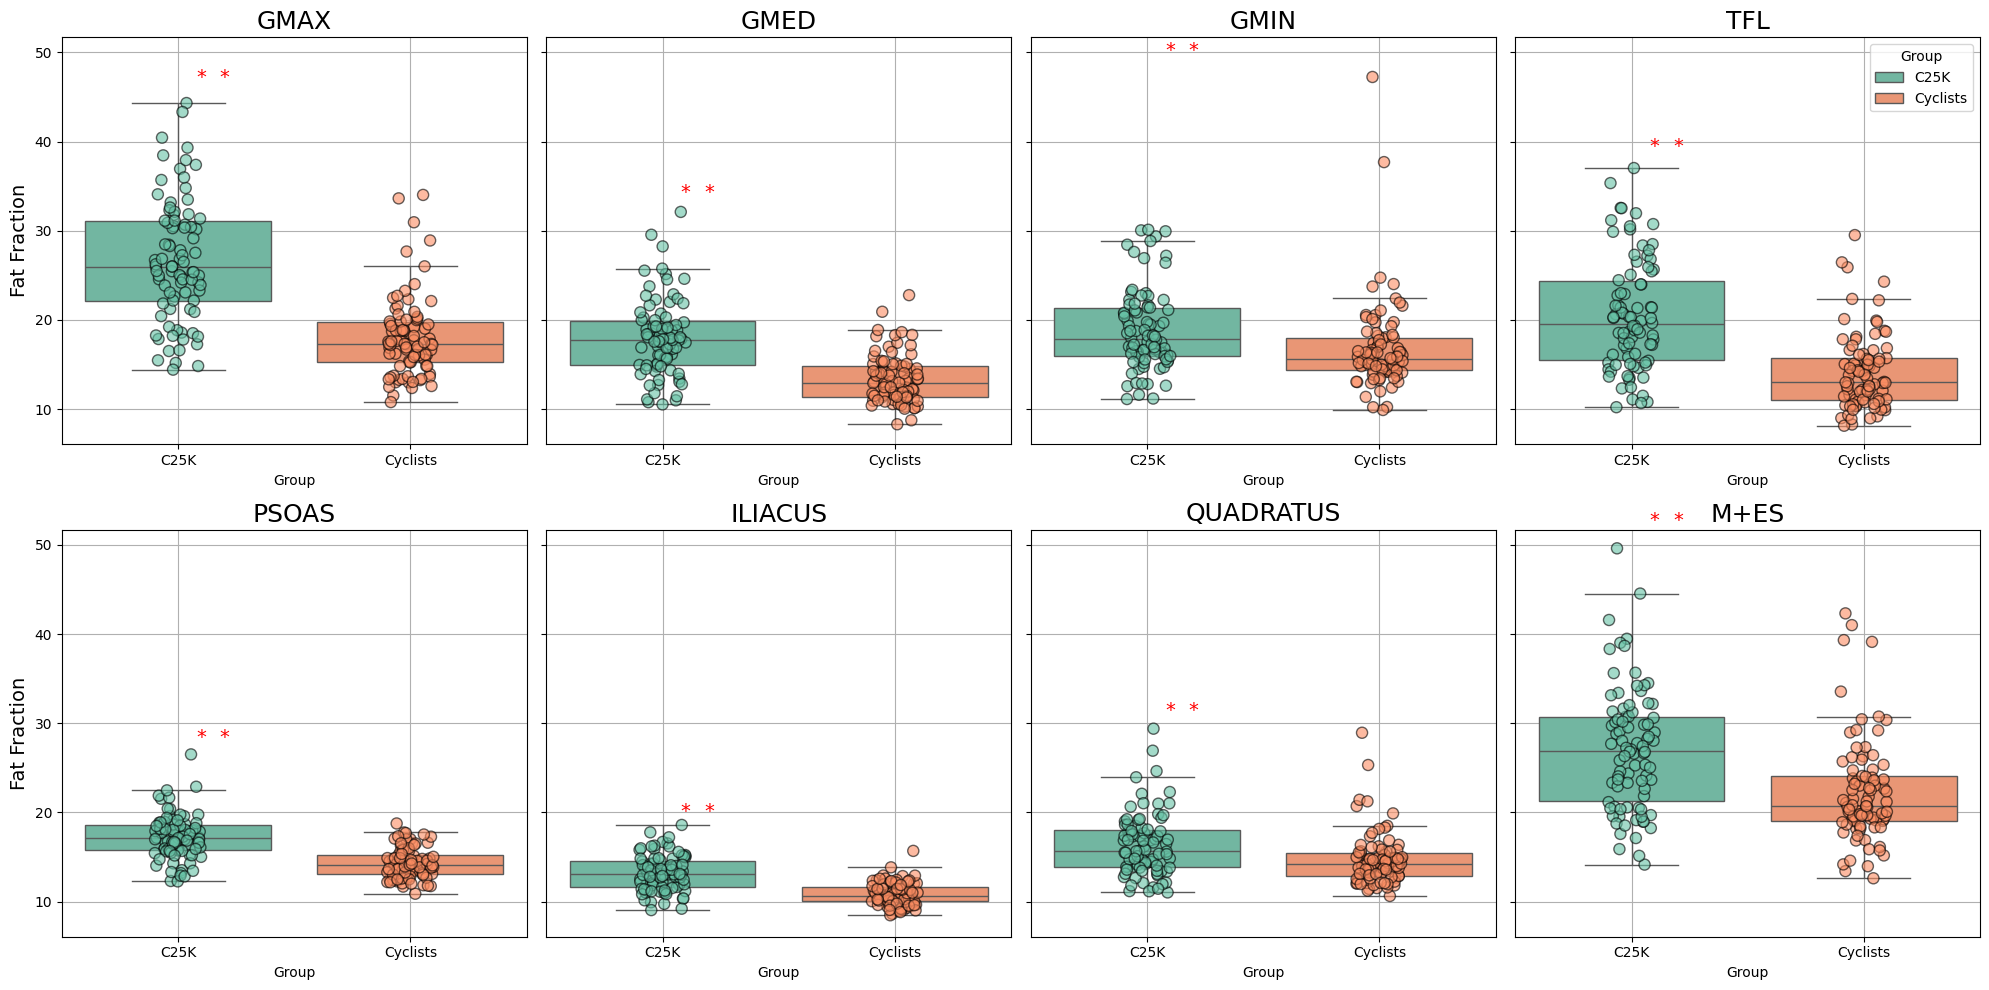

In [177]:
# Plot box plots for volume relative to total volume:

# Plot box plots for volume relative to total volume as subplots (panels)
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
muscle_list = ['GMAX', 'GMED', 'GMIN', 'TFL', 'PSOAS', 'ILIACUS', 'QUADRATUS', 'M+ES']

for i, muscle in enumerate(muscle_list):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x='Group', y=f'FF_{muscle}', data=filtered_data, showfliers=False, palette='Set2', hue='Group', legend=True, ax=ax)
    sns.stripplot(
        x='Group', y=f'FF_{muscle}', data=filtered_data,
        palette='Set2', alpha=0.6, jitter=True, size=8, hue='Group', legend=False,
        edgecolor='black', linewidth=1, ax=ax
    )
    ax.set_ylabel('Fat Fraction', fontsize=14)
    ax.set_title(f'{muscle}', fontsize=18)
    ax.grid(True)
    # Add significance annotations
    pairs = [(group1, group2) for group1 in filtered_data['Group'].unique() for group2 in filtered_data['Group'].unique() if group1 != group2]
    for group1, group2 in pairs:
        group1_data = filtered_data[filtered_data['Group'] == group1][f'FF_{muscle}']
        group2_data = filtered_data[filtered_data['Group'] == group2][f'FF_{muscle}']
        #t_stat, p_val = stats.ttest_ind(group1_data.dropna(), group2_data.dropna(), equal_var=False)
        # Perform Kruskal-Wallis test
        stat, p_val = stats.kruskal(
            *[filtered_data[filtered_data['Group'] == group][f'FF_{muscle}'].dropna() 
              for group in filtered_data['Group'].unique()]
        )
        if p_val < 0.05:  # Significant difference
            y_max = max(group1_data.max(), group2_data.max())
            ax.text((pairs.index((group1, group2)) + 1) * 0.1, y_max * 1.05, '*', fontsize=14, color='red', ha='center')
    # Only show legend for the fourth plot (top right: i == 3)
    if i == 3:
        if ax.get_legend():
            ax.legend(title='Group')
    else:
        if ax.get_legend():
            ax.get_legend().remove()

plt.tight_layout()
plt.savefig(os.path.join(output_path, "boxplot_ff_all_muscles_by_group.png"))
plt.show()

In [178]:
# Define a function to calculate median and IQR
def median_iqr(series):
    median = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{median:.1f} ({q1:.1f} - {q3:.1f})"

# Initialize an empty dictionary to store results
results = {}
# Compute stats for each muscle and 'LEAN_NORM_VOL_TOTAL' and 'FF_TOTAL'
musclestoassess = muscles + ['TOTAL']
# Iterate over each muscle and variable
for var in ['FF']:#['VOL', 'NORM_VOL', 'LEAN_NORM_VOL', 'NORMH_VOL', 'LEAN_NORMH_VOL', 'NORMH2_VOL', 'LEAN_NORMH2_VOL']:
    results[var] = {}
    for muscle in musclestoassess:
        column = f"{var}_{muscle}"
        if column in filtered_data.columns:
            # Group by 'Group' and calculate median (IQR) for each group
            results[var][muscle] = filtered_data.groupby('Group')[column].apply(median_iqr)

# Convert the results dictionary to a DataFrame
results_df = pd.concat({var: pd.DataFrame(data).T for var, data in results.items()}, axis=0)
# Print the results DataFrame to display it nicely
print("\nMedian (IQR) for Fat Fraction by Group:")
print(results_df)
# Save the results to a CSV file
results_table_path = os.path.join(output_path, "median_iqr_table.csv")
results_df.to_csv(results_table_path)
print(f"Median (IQR) table saved to {results_table_path}")

# Display the table
results_df



Median (IQR) for Fat Fraction by Group:
Group                       C25K            Cyclists
FF GMAX       26.0 (22.2 - 31.1)  17.3 (15.2 - 19.8)
   GMED       17.8 (15.0 - 19.9)  13.0 (11.4 - 14.9)
   GMIN       17.9 (16.0 - 21.3)  15.7 (14.3 - 18.0)
   TFL        19.5 (15.5 - 24.3)  13.0 (11.1 - 15.7)
   PSOAS      17.2 (15.8 - 18.6)  14.1 (13.1 - 15.2)
   ILIACUS    13.0 (11.6 - 14.6)  10.6 (10.0 - 11.6)
   QUADRATUS  15.7 (13.9 - 18.1)  14.2 (12.9 - 15.5)
   M+ES       26.9 (21.3 - 30.8)  20.8 (19.1 - 24.1)
   TOTAL      22.1 (18.9 - 25.8)  16.0 (14.5 - 17.9)
Median (IQR) table saved to G:/My Drive/Work/Publications/2025_CoreScore/SubmissionSkeletalRadiology/Rev1/Results/median_iqr_table.csv


Group                       C25K            Cyclists
FF GMAX       26.0 (22.2 - 31.1)  17.3 (15.2 - 19.8)
   GMED       17.8 (15.0 - 19.9)  13.0 (11.4 - 14.9)
   GMIN       17.9 (16.0 - 21.3)  15.7 (14.3 - 18.0)
   TFL        19.5 (15.5 - 24.3)  13.0 (11.1 - 15.7)
   PSOAS      17.2 (15.8 - 18.6)  14.1 (13.1 - 15.2)
   ILIACUS    13.0 (11.6 - 14.6)  10.6 (10.0 - 11.6)
   QUADRATUS  15.7 (13.9 - 18.1)  14.2 (12.9 - 15.5)
   M+ES       26.9 (21.3 - 30.8)  20.8 (19.1 - 24.1)
   TOTAL      22.1 (18.9 - 25.8)  16.0 (14.5 - 17.9)

In [179]:
from statsmodels.stats.anova import anova_lm

# Add partial eta squared calculation to the ANCOVA results
ancova_results = {}

# Function to compute 95% CI for coefficients
def get_coef_with_ci(model):
    conf_int = model.conf_int()
    coef_ci = {}
    for param in model.params.index:
        coef = model.params[param]
        ci_lower = conf_int.loc[param, 0]
        ci_upper = conf_int.loc[param, 1]
        coef_ci[param] = f"{coef:.4f} ({ci_lower:.4f}, {ci_upper:.4f})"
    return coef_ci

# Compute stats for each muscle and 'LEAN_NORM_VOL_TOTAL' and 'FF_TOTAL'
musclestoassess = muscles + ['TOTAL']
for muscle in musclestoassess:
    column = f'FF_{muscle}' if muscle != 'TOTAL' else 'FF_TOTAL'
    column_for_analysis = column.replace('+', '')
    ancova_data = filtered_data[['Group', 'Sex', 'Age', 'BMI', column]].dropna()
    ancova_data = ancova_data.rename(columns={column: column_for_analysis})
    
    formula = f'{column_for_analysis} ~ C(Group) + C(Sex) + Age + BMI'
    model = ols(formula, data=ancova_data).fit()
    ancova_table = anova_lm(model, typ=3)
    
    # Calculate partial eta squared for each factor
    # Partial eta squared = SS_effect / (SS_effect + SS_residual)
    ss_residual = ancova_table.loc['Residual', 'sum_sq']
    
    ancova_results[muscle] = {
        'model': model,
        'anova_table': ancova_table,
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj,
        'coefficients': model.params,
        'partial_eta_sq_group': ancova_table.loc['C(Group)', 'sum_sq'] / (ancova_table.loc['C(Group)', 'sum_sq'] + ss_residual),
        'partial_eta_sq_sex': ancova_table.loc['C(Sex)', 'sum_sq'] / (ancova_table.loc['C(Sex)', 'sum_sq'] + ss_residual),
        'partial_eta_sq_age': ancova_table.loc['Age', 'sum_sq'] / (ancova_table.loc['Age', 'sum_sq'] + ss_residual),
        'partial_eta_sq_bmi': ancova_table.loc['BMI', 'sum_sq'] / (ancova_table.loc['BMI', 'sum_sq'] + ss_residual)
    }
    
    print(f"\n{'='*60}")
    print(f"ANCOVA Results for {muscle} Fat Fraction")
    print(f"{'='*60}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"\nRegression Coefficients with 95% CI:")
    coef_ci = get_coef_with_ci(model)
    for param, value in coef_ci.items():
        print(f"  {param}: {value}")
    print(f"\nANOVA Table (Type III):")
    print(ancova_table)
    print(f"\nPartial Eta Squared:")
    print(f"  Group: {ancova_results[muscle]['partial_eta_sq_group']:.4f}")
    print(f"  Sex: {ancova_results[muscle]['partial_eta_sq_sex']:.4f}")
    print(f"  Age: {ancova_results[muscle]['partial_eta_sq_age']:.4f}")
    print(f"  BMI: {ancova_results[muscle]['partial_eta_sq_bmi']:.4f}")

# Update summary table to include partial eta squared
summary_data = []
for muscle in muscles:
    anova_table = ancova_results[muscle]['anova_table']
    summary_data.append({
        'Muscle': muscle,
        'Group_F': anova_table.loc['C(Group)', 'F'],
        'Group_p': anova_table.loc['C(Group)', 'PR(>F)'],
        'Group_η²p': ancova_results[muscle]['partial_eta_sq_group'],
        'Sex_F': anova_table.loc['C(Sex)', 'F'],
        'Sex_p': anova_table.loc['C(Sex)', 'PR(>F)'],
        'Sex_η²p': ancova_results[muscle]['partial_eta_sq_sex'],
        'Age_F': anova_table.loc['Age', 'F'],
        'Age_p': anova_table.loc['Age', 'PR(>F)'],
        'Age_η²p': ancova_results[muscle]['partial_eta_sq_age'],
        'BMI_F': anova_table.loc['BMI', 'F'],
        'BMI_p': anova_table.loc['BMI', 'PR(>F)'],
        'BMI_η²p': ancova_results[muscle]['partial_eta_sq_bmi'],
        'R_squared': ancova_results[muscle]['r_squared'],
        'Adj_R_squared': ancova_results[muscle]['adj_r_squared']
    })

ancova_summary_df = pd.DataFrame(summary_data)

print(f"\n{'='*60}")
print("ANCOVA Summary for All Muscles (with Partial Eta Squared)")
print(f"{'='*60}")
print(ancova_summary_df.to_string(index=False))

ancova_summary_path = os.path.join(output_path, "ancova_summary_ff_with_eta_squared.csv")
ancova_summary_df.to_csv(ancova_summary_path, index=False)
print(f"\nANCOVA summary with partial eta squared saved to {ancova_summary_path}")



ANCOVA Results for GMAX Fat Fraction
R-squared: 0.6029
Adjusted R-squared: 0.5934

Regression Coefficients with 95% CI:
  Intercept: 4.5905 (-0.4285, 9.6095)
  C(Group)[T.Cyclists]: -5.3244 (-6.9482, -3.7007)
  C(Sex)[T.Male]: -3.2037 (-4.6005, -1.8069)
  Age: 0.1349 (0.0785, 0.1914)
  BMI: 0.6178 (0.4621, 0.7735)

ANOVA Table (Type III):
                sum_sq     df          F        PR(>F)
Intercept    68.324189    1.0   3.260587  7.276465e-02
C(Group)    878.207288    1.0  41.910070  1.021566e-09
C(Sex)      429.636238    1.0  20.503229  1.127809e-05
Age         466.636958    1.0  22.268988  4.986534e-06
BMI        1285.912211    1.0  61.366686  5.242486e-13
Residual   3499.412335  167.0        NaN           NaN

Partial Eta Squared:
  Group: 0.2006
  Sex: 0.1093
  Age: 0.1177
  BMI: 0.2687

ANCOVA Results for GMED Fat Fraction
R-squared: 0.6317
Adjusted R-squared: 0.6229

Regression Coefficients with 95% CI:
  Intercept: 2.0594 (-0.7917, 4.9105)
  C(Group)[T.Cyclists]: -2.4661 (-

In [180]:
# Calculate median and IQR for FF by sex within each group
def median_iqr(series):
    median = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return f"{median:.1f} ({q1:.1f} - {q3:.1f})"

# Initialize dictionary to store results
results_by_sex = {}

for muscle in musclestoassess:
    column = f"FF_{muscle}"
    if column in filtered_data.columns:
        # Group by both 'Group' and 'Sex', then calculate median (IQR)
        results_by_sex[muscle] = filtered_data.groupby(['Group', 'Sex'])[column].apply(median_iqr)

# Convert to DataFrame with MultiIndex
results_by_sex_df = pd.DataFrame(results_by_sex).T

print("\nMedian (IQR) for Fat Fraction by Group and Sex:")
print(results_by_sex_df)

# Save to CSV
results_by_sex_path = os.path.join(output_path, "median_iqr_ff_by_group_and_sex.csv")
results_by_sex_df.to_csv(results_by_sex_path)
print(f"\nMedian (IQR) by group and sex table saved to {results_by_sex_path}")


Median (IQR) for Fat Fraction by Group and Sex:
Group                    C25K                                Cyclists  \
Sex                    Female                Male              Female   
GMAX       28.8 (24.2 - 33.0)  24.9 (20.1 - 27.2)  17.3 (15.2 - 20.0)   
GMED       18.2 (16.3 - 21.6)  17.5 (14.8 - 18.9)  12.2 (11.3 - 15.0)   
GMIN       19.4 (16.1 - 22.7)  17.3 (15.9 - 19.9)  15.5 (14.4 - 17.0)   
TFL        22.8 (19.2 - 28.2)  17.2 (14.1 - 19.8)  13.5 (11.1 - 17.1)   
PSOAS      17.7 (16.3 - 18.7)  16.7 (15.2 - 18.5)  13.7 (12.7 - 14.9)   
ILIACUS    13.1 (12.0 - 14.8)  13.0 (11.2 - 14.3)  10.5 (10.0 - 11.5)   
QUADRATUS  17.3 (14.3 - 18.9)  15.0 (13.4 - 16.9)  14.6 (13.1 - 15.8)   
M+ES       30.3 (27.7 - 33.6)  23.4 (19.5 - 26.8)  22.5 (19.8 - 26.2)   
TOTAL      24.4 (22.0 - 27.2)  20.3 (17.6 - 23.0)  16.2 (14.7 - 19.7)   

Group                          
Sex                      Male  
GMAX       17.3 (15.3 - 18.8)  
GMED       13.1 (12.0 - 14.5)  
GMIN       16.4 (14

In [181]:
# Calculate median and IQR for LEAN_NORM_VOL by sex within each group
results_by_sex_lnv = {}

for muscle in musclestoassess:
    column = f"LEAN_NORM_VOL_{muscle}"
    if column in filtered_data.columns:
        # Group by both 'Group' and 'Sex', then calculate median (IQR)
        results_by_sex_lnv[muscle] = filtered_data.groupby(['Group', 'Sex'])[column].apply(median_iqr)

# Convert to DataFrame with MultiIndex
results_by_sex_lnv_df = pd.DataFrame(results_by_sex_lnv).T

print("\nMedian (IQR) for Lean Normalized Volume by Group and Sex:")
print(results_by_sex_lnv_df)

# Save to CSV
results_by_sex_lnv_path = os.path.join(output_path, "median_iqr_lean_norm_vol_by_group_and_sex.csv")
results_by_sex_lnv_df.to_csv(results_by_sex_lnv_path)
print(f"\nMedian (IQR) by group and sex table saved to {results_by_sex_lnv_path}")



Median (IQR) for Lean Normalized Volume by Group and Sex:
Group                    C25K                                Cyclists  \
Sex                    Female                Male              Female   
GMAX          5.3 (4.8 - 5.9)     6.1 (5.6 - 7.0)     7.7 (6.9 - 8.5)   
GMED          3.1 (2.6 - 3.4)     3.5 (3.3 - 3.9)     4.0 (3.8 - 4.5)   
GMIN          0.7 (0.6 - 0.8)     0.9 (0.8 - 1.0)     1.0 (0.8 - 1.1)   
TFL           0.3 (0.2 - 0.4)     0.5 (0.3 - 0.5)     0.5 (0.4 - 0.6)   
PSOAS         1.5 (1.3 - 1.8)     2.2 (1.9 - 2.7)     2.4 (2.0 - 2.7)   
ILIACUS       1.4 (1.2 - 1.5)     1.9 (1.6 - 2.1)     2.1 (1.9 - 2.3)   
QUADRATUS     0.3 (0.3 - 0.4)     0.5 (0.4 - 0.5)     0.4 (0.4 - 0.5)   
M+ES          2.7 (2.3 - 3.1)     3.3 (2.9 - 4.0)     3.9 (3.5 - 4.1)   
TOTAL      15.0 (13.7 - 17.2)  19.1 (17.4 - 21.3)  22.2 (20.4 - 23.7)   

Group                          
Sex                      Male  
GMAX          8.0 (7.2 - 9.2)  
GMED          4.4 (4.1 - 4.8)  
GMIN     

In [182]:
from scipy.stats import kstest, shapiro

# Perform Kolmogorov-Smirnov test for normality on FF and normalized lean volume variables
normality_results = []

for muscle in muscles:
    # Test Fat Fraction (FF)
    ff_column = f'FF_{muscle}'
    ff_data = filtered_data[ff_column].dropna()
    
    # Kolmogorov-Smirnov test
    ks_stat_ff, ks_p_ff = kstest(ff_data, 'norm', args=(ff_data.mean(), ff_data.std()))
    
    # Shapiro-Wilk test (more powerful for small to medium samples)
    shapiro_stat_ff, shapiro_p_ff = shapiro(ff_data)
    
    # Test Lean Normalized Volume
    lean_norm_vol_column = f'LEAN_NORM_VOL_{muscle}'
    lean_norm_vol_data = filtered_data[lean_norm_vol_column].dropna()
    
    # Kolmogorov-Smirnov test
    ks_stat_lnv, ks_p_lnv = kstest(lean_norm_vol_data, 'norm', 
                                     args=(lean_norm_vol_data.mean(), lean_norm_vol_data.std()))
    
    # Shapiro-Wilk test
    shapiro_stat_lnv, shapiro_p_lnv = shapiro(lean_norm_vol_data)
    
    normality_results.append({
        'Muscle': muscle,
        'FF_KS_statistic': ks_stat_ff,
        'FF_KS_p_value': ks_p_ff,
        'FF_Shapiro_statistic': shapiro_stat_ff,
        'FF_Shapiro_p_value': shapiro_p_ff,
        'FF_Normal_KS': 'Yes' if ks_p_ff > 0.05 else 'No',
        'FF_Normal_Shapiro': 'Yes' if shapiro_p_ff > 0.05 else 'No',
        'LNV_KS_statistic': ks_stat_lnv,
        'LNV_KS_p_value': ks_p_lnv,
        'LNV_Shapiro_statistic': shapiro_stat_lnv,
        'LNV_Shapiro_p_value': shapiro_p_lnv,
        'LNV_Normal_KS': 'Yes' if ks_p_lnv > 0.05 else 'No',
        'LNV_Normal_Shapiro': 'Yes' if shapiro_p_lnv > 0.05 else 'No'
    })

normality_df = pd.DataFrame(normality_results)

print("\n" + "="*80)
print("Normality Tests for Fat Fraction (FF) and Lean Normalized Volume (LNV)")
print("="*80)
print(normality_df.to_string(index=False))

# Save results
normality_test_path = os.path.join(output_path, "normality_tests_ff_lnv.csv")
normality_df.to_csv(normality_test_path, index=False)
print(f"\nNormality test results saved to {normality_test_path}")


Normality Tests for Fat Fraction (FF) and Lean Normalized Volume (LNV)
   Muscle  FF_KS_statistic  FF_KS_p_value  FF_Shapiro_statistic  FF_Shapiro_p_value FF_Normal_KS FF_Normal_Shapiro  LNV_KS_statistic  LNV_KS_p_value  LNV_Shapiro_statistic  LNV_Shapiro_p_value LNV_Normal_KS LNV_Normal_Shapiro
     GMAX         0.115092       0.019291              0.942128        1.889091e-06           No                No          0.069293        0.364040               0.980055             0.014224           Yes                 No
     GMED         0.087857       0.132361              0.940074        1.282732e-06          Yes                No          0.040252        0.932585               0.992212             0.482456           Yes                Yes
     GMIN         0.129542       0.005625              0.846726        3.769073e-12           No                No          0.066562        0.413195               0.986910             0.109436           Yes                Yes
      TFL         0.1076

In [183]:
# ANCOVA Analysis for Lean Normalized Volume

# Add partial eta squared calculation to the ANCOVA results for LEAN_NORM_VOL
ancova_results_lnv = {}

# Compute stats for each muscle and 'LEAN_NORM_VOL_TOTAL'
musclestoassess = muscles + ['TOTAL']
for muscle in musclestoassess:
    column = f'LEAN_NORM_VOL_{muscle}' if muscle != 'TOTAL' else 'LEAN_NORM_VOL_TOTAL'
    column_for_analysis = column.replace('+', '')
    ancova_data = filtered_data[['Group', 'Sex', 'Age', 'BMI', column]].dropna()
    ancova_data = ancova_data.rename(columns={column: column_for_analysis})
    
    formula = f'{column_for_analysis} ~ C(Group) + C(Sex) + Age + BMI'
    model = ols(formula, data=ancova_data).fit()
    ancova_table = anova_lm(model, typ=3)
    
    # Calculate partial eta squared for each factor
    ss_residual = ancova_table.loc['Residual', 'sum_sq']
    
    ancova_results_lnv[muscle] = {
        'model': model,
        'anova_table': ancova_table,
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj,
        'coefficients': model.params,
        'partial_eta_sq_group': ancova_table.loc['C(Group)', 'sum_sq'] / (ancova_table.loc['C(Group)', 'sum_sq'] + ss_residual),
        'partial_eta_sq_sex': ancova_table.loc['C(Sex)', 'sum_sq'] / (ancova_table.loc['C(Sex)', 'sum_sq'] + ss_residual),
        'partial_eta_sq_age': ancova_table.loc['Age', 'sum_sq'] / (ancova_table.loc['Age', 'sum_sq'] + ss_residual),
        'partial_eta_sq_bmi': ancova_table.loc['BMI', 'sum_sq'] / (ancova_table.loc['BMI', 'sum_sq'] + ss_residual)
    }
    
    print(f"\n{'='*60}")
    print(f"ANCOVA Results for {muscle} Lean Normalized Volume")
    print(f"{'='*60}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"\nRegression Coefficients with 95% CI:")
    coef_ci = get_coef_with_ci(model)
    for param, value in coef_ci.items():
        print(f"  {param}: {value}")
    print(f"\nANOVA Table (Type III):")
    print(ancova_table)
    print(f"\nPartial Eta Squared:")
    print(f"  Group: {ancova_results_lnv[muscle]['partial_eta_sq_group']:.4f}")
    print(f"  Sex: {ancova_results_lnv[muscle]['partial_eta_sq_sex']:.4f}")
    print(f"  Age: {ancova_results_lnv[muscle]['partial_eta_sq_age']:.4f}")
    print(f"  BMI: {ancova_results_lnv[muscle]['partial_eta_sq_bmi']:.4f}")

# Create summary table with partial eta squared
summary_data_lnv = []
for muscle in muscles:
    anova_table = ancova_results_lnv[muscle]['anova_table']
    summary_data_lnv.append({
        'Muscle': muscle,
        'Group_F': anova_table.loc['C(Group)', 'F'],
        'Group_p': anova_table.loc['C(Group)', 'PR(>F)'],
        'Group_η²p': ancova_results_lnv[muscle]['partial_eta_sq_group'],
        'Sex_F': anova_table.loc['C(Sex)', 'F'],
        'Sex_p': anova_table.loc['C(Sex)', 'PR(>F)'],
        'Sex_η²p': ancova_results_lnv[muscle]['partial_eta_sq_sex'],
        'Age_F': anova_table.loc['Age', 'F'],
        'Age_p': anova_table.loc['Age', 'PR(>F)'],
        'Age_η²p': ancova_results_lnv[muscle]['partial_eta_sq_age'],
        'BMI_F': anova_table.loc['BMI', 'F'],
        'BMI_p': anova_table.loc['BMI', 'PR(>F)'],
        'BMI_η²p': ancova_results_lnv[muscle]['partial_eta_sq_bmi'],
        'R_squared': ancova_results_lnv[muscle]['r_squared'],
        'Adj_R_squared': ancova_results_lnv[muscle]['adj_r_squared']
    })

ancova_summary_lnv_df = pd.DataFrame(summary_data_lnv)

print(f"\n{'='*60}")
print("ANCOVA Summary for All Muscles - Lean Normalized Volume (with Partial Eta Squared)")
print(f"{'='*60}")
print(ancova_summary_lnv_df.to_string(index=False))

ancova_summary_lnv_path = os.path.join(output_path, "ancova_summary_lean_norm_vol_with_eta_squared.csv")
ancova_summary_lnv_df.to_csv(ancova_summary_lnv_path, index=False)
print(f"\nANCOVA summary with partial eta squared saved to {ancova_summary_lnv_path}")

# Calculate median and IQR for LEAN_NORM_VOL by sex within each group
results_by_sex_lnv = {}

for muscle in musclestoassess:
    column = f"LEAN_NORM_VOL_{muscle}"
    if column in filtered_data.columns:
        # Group by both 'Group' and 'Sex', then calculate median (IQR)
        results_by_sex_lnv[muscle] = filtered_data.groupby(['Group', 'Sex'])[column].apply(median_iqr)

# Convert to DataFrame with MultiIndex
results_by_sex_lnv_df = pd.DataFrame(results_by_sex_lnv).T

print("\nMedian (IQR) for Lean Normalized Volume by Group and Sex:")
print(results_by_sex_lnv_df)

# Save to CSV
results_by_sex_lnv_path = os.path.join(output_path, "median_iqr_lean_norm_vol_by_group_and_sex.csv")
results_by_sex_lnv_df.to_csv(results_by_sex_lnv_path)
print(f"\nMedian (IQR) by group and sex table saved to {results_by_sex_lnv_path}")

# Calculate overall median and IQR for LEAN_NORM_VOL by group
results_lnv = {}
results_lnv['LEAN_NORM_VOL'] = {}

for muscle in musclestoassess:
    column = f"LEAN_NORM_VOL_{muscle}"
    if column in filtered_data.columns:
        results_lnv['LEAN_NORM_VOL'][muscle] = filtered_data.groupby('Group')[column].apply(median_iqr)

# Convert to DataFrame
results_lnv_df = pd.concat({var: pd.DataFrame(data).T for var, data in results_lnv.items()}, axis=0)

print("\nMedian (IQR) for Lean Normalized Volume by Group:")
print(results_lnv_df)

# Save to CSV
results_lnv_table_path = os.path.join(output_path, "median_iqr_lean_norm_vol_table.csv")
results_lnv_df.to_csv(results_lnv_table_path)
print(f"Median (IQR) table for lean normalized volume saved to {results_lnv_table_path}")



ANCOVA Results for GMAX Lean Normalized Volume
R-squared: 0.5473
Adjusted R-squared: 0.5365

Regression Coefficients with 95% CI:
  Intercept: 9.2218 (7.9712, 10.4724)
  C(Group)[T.Cyclists]: 1.5986 (1.1940, 2.0032)
  C(Sex)[T.Male]: 0.8722 (0.5241, 1.2202)
  Age: -0.0212 (-0.0353, -0.0071)
  BMI: -0.1005 (-0.1393, -0.0617)

ANOVA Table (Type III):
               sum_sq     df           F        PR(>F)
Intercept  275.731120    1.0  211.931660  1.588923e-31
C(Group)    79.162208    1.0   60.845428  6.363644e-13
C(Sex)      31.843256    1.0   24.475272  1.823821e-06
Age         11.536025    1.0    8.866786  3.336448e-03
BMI         33.993623    1.0   26.128081  8.667939e-07
Residual   217.273328  167.0         NaN           NaN

Partial Eta Squared:
  Group: 0.2670
  Sex: 0.1278
  Age: 0.0504
  BMI: 0.1353

ANCOVA Results for GMED Lean Normalized Volume
R-squared: 0.5746
Adjusted R-squared: 0.5644

Regression Coefficients with 95% CI:
  Intercept: 5.2146 (4.6311, 5.7981)
  C(Group)[T.Cy

0      Physically Inactive
2      Physically Inactive
3      Physically Inactive
4      Physically Inactive
5      Physically Inactive
              ...         
192               Cyclists
193               Cyclists
194               Cyclists
195               Cyclists
202               Cyclists
Name: Group, Length: 172, dtype: object
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Physically Inactive vs. Cyclists: Custom statistical test, P_val:5.615e-15


C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\1672102091.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=col_ff, data=df, order=desired_group_order, palette=custom_palette, linewidth=4, showfliers=False, ax=ax)
C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\1672102091.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Group', y=col_ff, data=df, order=desired_group_order, palette=custom_palette, alpha=0.6, jitter=True, size=6, edgecolor='black', linewidth=1, ax=ax)
C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\1672102091.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Physically Inactive vs. Cyclists: Custom statistical test, P_val:2.148e-16
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Male vs. Female: Custom statistical test, P_val:3.033e-02


C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\1672102091.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y=col_ff, data=df, order=sex_present, palette=sex_palette, linewidth=4, showfliers=False, ax=ax)
C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\1672102091.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Sex', y=col_ff, data=df, order=sex_present, palette=sex_palette, alpha=0.6, jitter=True, size=6, edgecolor='black', linewidth=1, ax=ax)
C:\Users\mabel\AppData\Local\Temp\ipykernel_10752\1672102091.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Male vs. Female: Custom statistical test, P_val:3.730e-04
Figure saved to: G:/My Drive/Work/Publications/2025_CoreScore/SubmissionSkeletalRadiology/Rev1/Results/figure_core_ff_lnv_by_group_and_sex.png


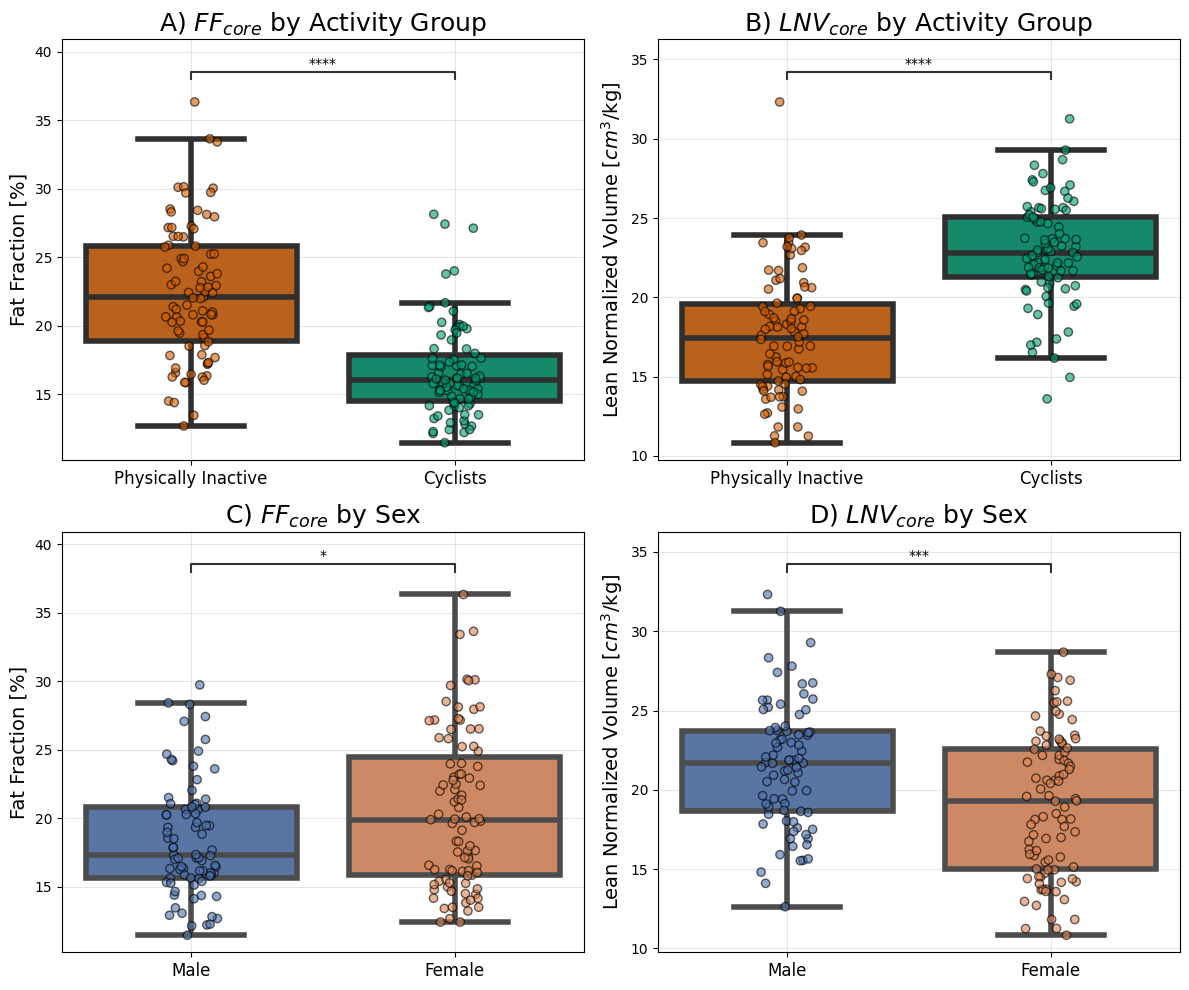

In [184]:
# Figure: Core FF and Core LNV by activity group and by sex (2x2)
import itertools
import os
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from scikit_posthocs import posthoc_dunn
import scipy.stats as stats


df = filtered_data
df['Group'] = df['Group'].replace({'C25K': 'Physically Inactive'})
print(df['Group'])
# Columns to plot (check availability)
col_ff = 'FF_TOTAL'
col_lnv = 'LEAN_NORM_VOL_TOTAL'
for col in (col_ff, col_lnv):
    if col not in df.columns:
        raise RuntimeError(f"Required column '{col}' not found in dataframe. Available columns: {list(df.columns)}")

# Define desired order and palettes
desired_group_order = ['Physically Inactive', 'Cyclists']
df['Group'] = pd.Categorical(df['Group'], categories=desired_group_order, ordered=True)
custom_palette = {
    'Physically Inactive': '#D55E00',
    'Cyclists': '#009E73'
}

sex_order = ['Male', 'Female']
sex_palette = {'Male': '#4C72B0', 'Female': '#DD8452'}

# Create figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)

# Top-left: FF by Group
ax = axes[0, 0]
sns.boxplot(x='Group', y=col_ff, data=df, order=desired_group_order, palette=custom_palette, linewidth=4, showfliers=False, ax=ax)
sns.stripplot(x='Group', y=col_ff, data=df, order=desired_group_order, palette=custom_palette, alpha=0.6, jitter=True, size=6, edgecolor='black', linewidth=1, ax=ax)
ax.set_title('A) $FF_{core}$ by Activity Group', fontsize=18)
ax.set_ylabel('Fat Fraction [%]', fontsize=14)
ax.set_xlabel('Activity Group', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
# Remove the x-axis label (the "group title")
ax.set(xlabel=None)
ax.grid(True, alpha=0.3)

# Statistical annotation for Group (Kruskal-Wallis + Dunn)
present_groups = [g for g in desired_group_order if g in df['Group'].cat.categories and g in df['Group'].dropna().unique()]
if len(present_groups) >= 2:
    groups_for_test = [df[df['Group'] == g][col_ff].dropna().values for g in present_groups]
    try:
        stat, p = stats.kruskal(*groups_for_test)
        # post-hoc Dunn
        dunn_df = posthoc_dunn(df, val_col=col_ff, group_col='Group', p_adjust='fdr_bh')
        # build pairs and p-values in order
        pairs = list(itertools.combinations(present_groups, 2))
        p_values = [dunn_df.loc[a, b] if (a in dunn_df.index and b in dunn_df.columns) else dunn_df.loc[b, a] for a,b in pairs]
        annotator = Annotator(ax, pairs, data=df, x='Group', y=col_ff, order=present_groups)
        annotator.configure(text_format='star', loc='inside', hide_non_significant=True)
        annotator.set_pvalues_and_annotate(p_values)
    except Exception as e:
        print('Group FF stat test failed:', e)

# Top-right: LNV by Group
ax = axes[0, 1]
sns.boxplot(x='Group', y=col_lnv, data=df, order=desired_group_order, palette=custom_palette, linewidth=4, showfliers=False, legend=True, ax=ax)
sns.stripplot(x='Group', y=col_lnv, data=df, order=desired_group_order, palette=custom_palette, alpha=0.6, jitter=True, size=6, edgecolor='black', linewidth=1, ax=ax)
ax.set_title('B) $LNV_{core}$ by Activity Group', fontsize=18)
ax.set_ylabel('Lean Normalized Volume [$cm^{3}$/kg]', fontsize=14)
ax.set_xlabel('Activity Group', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
# Remove the x-axis label (the "group title")
ax.set(xlabel=None)
ax.grid(True, alpha=0.3)

# Statistical annotation for Group (Kruskal-Wallis + Dunn) on LNV
if len(present_groups) >= 2:
    groups_for_test = [df[df['Group'] == g][col_lnv].dropna().values for g in present_groups]
    try:
        stat, p = stats.kruskal(*groups_for_test)
        dunn_df = posthoc_dunn(df, val_col=col_lnv, group_col='Group', p_adjust='fdr_bh')
        pairs = list(itertools.combinations(present_groups, 2))
        p_values = [dunn_df.loc[a, b] if (a in dunn_df.index and b in dunn_df.columns) else dunn_df.loc[b, a] for a,b in pairs]
        annotator = Annotator(ax, pairs, data=df, x='Group', y=col_lnv, order=present_groups)
        annotator.configure(text_format='star', loc='inside', hide_non_significant=True)
        annotator.set_pvalues_and_annotate(p_values)
    except Exception as e:
        print('Group LNV stat test failed:', e)

# Bottom-left: FF by Sex
ax = axes[1, 0]
sex_present = [s for s in sex_order if s in df['Sex'].dropna().unique()]
sns.boxplot(x='Sex', y=col_ff, data=df, order=sex_present, palette=sex_palette, linewidth=4, showfliers=False, ax=ax)
sns.stripplot(x='Sex', y=col_ff, data=df, order=sex_present, palette=sex_palette, alpha=0.6, jitter=True, size=6, edgecolor='black', linewidth=1, ax=ax)
ax.set_title('C) $FF_{core}$ by Sex', fontsize=18)
ax.set_ylabel('Fat Fraction [%]', fontsize=14)
ax.set_xlabel('Sex', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
# Remove the x-axis label (the "group title")
ax.set(xlabel=None)
ax.grid(True, alpha=0.3)

# Statistical annotation for Sex (Mann-Whitney U)
if len(sex_present) == 2:
    a = df[df['Sex'] == sex_present[0]][col_ff].dropna()
    b = df[df['Sex'] == sex_present[1]][col_ff].dropna()
    try:
        u_stat, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
        annotator = Annotator(ax, [(sex_present[0], sex_present[1])], data=df, x='Sex', y=col_ff, order=sex_present)
        annotator.configure(text_format='star', loc='inside', hide_non_significant=True)
        annotator.set_pvalues_and_annotate([p_val])
    except Exception as e:
        print('Sex FF stat test failed:', e)

# Bottom-right: LNV by Sex
ax = axes[1, 1]
sns.boxplot(x='Sex', y=col_lnv, data=df, order=sex_present, palette=sex_palette, linewidth=4, showfliers=False, legend=True, ax=ax)
sns.stripplot(x='Sex', y=col_lnv, data=df, order=sex_present, palette=sex_palette, alpha=0.6, jitter=True, size=6, edgecolor='black', linewidth=1, ax=ax)
ax.set_title('D) $LNV_{core}$ by Sex', fontsize=18)
ax.set_ylabel('Lean Normalized Volume [$cm^{3}$/kg]', fontsize=14)
ax.set_xlabel('Sex', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
# Remove the x-axis label (the "group title")
ax.set(xlabel=None)
ax.grid(True, alpha=0.3)

# Statistical annotation for Sex on LNV
if len(sex_present) == 2:
    a = df[df['Sex'] == sex_present[0]][col_lnv].dropna()
    b = df[df['Sex'] == sex_present[1]][col_lnv].dropna()
    try:
        u_stat, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
        annotator = Annotator(ax, [(sex_present[0], sex_present[1])], data=df, x='Sex', y=col_lnv, order=sex_present)
        annotator.configure(text_format='star', loc='inside', hide_non_significant=True)
        annotator.set_pvalues_and_annotate([p_val])
    except Exception as e:
        print('Sex LNV stat test failed:', e)

plt.tight_layout()

# Save figure
out_file = os.path.join(output_path, 'figure_core_ff_lnv_by_group_and_sex.png')
plt.savefig(out_file, dpi=600)
print(f"Figure saved to: {out_file}")
plt.show()